# YOLO26 Vessel Detection - Model Capacity vs Overfitting

**Current Best:** imgsz=2560, epochs=100, yolo26s → mAP50=0.8791

**Key Finding:** More epochs caused overfitting (performance dropped at 150ep, crashed at 200ep)

**This Notebook Tests Two Hypotheses:**

1. **Model Capacity Hypothesis:** Is yolo26s too small? → Test yolo26m
2. **Overfitting Hypothesis:** Can stronger augmentation allow more epochs? → Test with augmentation

## 1. Setup

In [15]:
from ultralytics import YOLO
import torch
import time
import gc
import json
from datetime import datetime
from pathlib import Path

# Verify GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected!")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA B200
GPU Memory: 191.5 GB


In [16]:
# Paths
data_yaml_path = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/data.yaml"
progress_file = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/model_vs_augmentation_progress.json"

# Verify
if Path(data_yaml_path).exists():
    print(f"Data config found")
else:
    print(f"Data config NOT found: {data_yaml_path}")

Data config found


## 2. Helper Functions

In [17]:
def clear_memory():
    """Clear GPU and CPU memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def save_progress(results, filepath):
    """Save progress to JSON."""
    clean_results = []
    for r in results:
        clean_r = {}
        for k, v in r.items():
            if isinstance(v, (int, float, str, bool, type(None))):
                clean_r[k] = v
            else:
                clean_r[k] = str(v)
        clean_results.append(clean_r)
    
    with open(filepath, 'w') as f:
        json.dump(clean_results, f, indent=2)


def load_progress(filepath):
    """Load previous progress."""
    if Path(filepath).exists():
        with open(filepath, 'r') as f:
            return json.load(f)
    return []


def get_gpu_memory():
    """Get GPU memory usage."""
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        return f"{used:.1f}/{total:.1f} GB"
    return "N/A"

## 3. Define Baseline and Experiments

**Baseline:**
- Model: yolo26s.pt
- imgsz: 2560
- epochs: 100
- batch: 2
- mosaic: 0.5
- mixup: 0.0
- copy_paste: 0.0
- degrees: 0.0

In [18]:
# Baseline configuration
BASELINE_CONFIG = {
    'data': data_yaml_path,
    'imgsz': 2560,
    'epochs': 100,
    'batch': 2,
    'rect': True,
    'device': 0,
    
    # Baseline augmentations
    'mosaic': 0.5,
    'mixup': 0.0,
    'copy_paste': 0.0,
    'degrees': 0.0,
    'scale': 0.2,
    'fliplr': 0.5,
    'flipud': 0.0,
    
    # Training settings
    'patience': 30,
    'save': True,
    'plots': True,
    'project': 'jupiter_inlet_model_vs_aug',
    'workers': 4,
}

BASELINE_MODEL = 'yolo26s.pt'
BASELINE_mAP50 = 0.8791

print("Baseline Configuration:")
print(f"  Model: {BASELINE_MODEL}")
print(f"  imgsz: {BASELINE_CONFIG['imgsz']}")
print(f"  epochs: {BASELINE_CONFIG['epochs']}")
print(f"  batch: {BASELINE_CONFIG['batch']}")
print(f"  mosaic: {BASELINE_CONFIG['mosaic']}")
print(f"  mixup: {BASELINE_CONFIG['mixup']}")
print(f"  copy_paste: {BASELINE_CONFIG['copy_paste']}")
print(f"  degrees: {BASELINE_CONFIG['degrees']}")
print(f"Baseline mAP50: {BASELINE_mAP50}")

Baseline Configuration:
  Model: yolo26s.pt
  imgsz: 2560
  epochs: 100
  batch: 2
  mosaic: 0.5
  mixup: 0.0
  copy_paste: 0.0
  degrees: 0.0
Baseline mAP50: 0.8791


In [19]:
# Define experiments
experiments = [
    # ==========================================================================
    # HYPOTHESIS 1: Model Capacity
    # Change: model yolo26s → yolo26m
    # Everything else: SAME as baseline
    # ==========================================================================
    {
        'name': 'larger_model_yolo26m',
        'hypothesis': 'Model Capacity',
        'change': 'model: yolo26s → yolo26m',
        'model': 'yolo26m.pt',
        'config_changes': {
            'batch': 1,  # Reduce batch for larger model to fit in memory
        },
    },
    
    # ==========================================================================
    # HYPOTHESIS 2a: Overfitting - Test stronger mosaic
    # Change: mosaic 0.5 → 1.0
    # Everything else: SAME as baseline
    # ==========================================================================
    {
        'name': 'stronger_mosaic',
        'hypothesis': 'Overfitting',
        'change': 'mosaic: 0.5 → 1.0',
        'model': 'yolo26s.pt',
        'config_changes': {
            'mosaic': 1.0,
        },
    },
    
    # ==========================================================================
    # HYPOTHESIS 2b: Overfitting - Test mixup
    # Change: mixup 0.0 → 0.15
    # Everything else: SAME as baseline
    # ==========================================================================
    {
        'name': 'add_mixup',
        'hypothesis': 'Overfitting',
        'change': 'mixup: 0.0 → 0.15',
        'model': 'yolo26s.pt',
        'config_changes': {
            'mixup': 0.15,
        },
    },
    
    # ==========================================================================
    # HYPOTHESIS 2c: Overfitting - Test copy_paste
    # Change: copy_paste 0.0 → 0.1
    # Everything else: SAME as baseline
    # ==========================================================================
    {
        'name': 'add_copy_paste',
        'hypothesis': 'Overfitting',
        'change': 'copy_paste: 0.0 → 0.1',
        'model': 'yolo26s.pt',
        'config_changes': {
            'copy_paste': 0.1,
        },
    },
    
    # ==========================================================================
    # HYPOTHESIS 2d: Overfitting - Test rotation
    # Change: degrees 0.0 → 10.0
    # Everything else: SAME as baseline
    # ==========================================================================
    {
        'name': 'add_rotation',
        'hypothesis': 'Overfitting',
        'change': 'degrees: 0.0 → 10.0',
        'model': 'yolo26s.pt',
        'config_changes': {
            'degrees': 10.0,
        },
    },
]

print(f"Total experiments: {len(experiments)}")
print("\nExperiment Design (one change at a time):")
print("-" * 70)
for i, exp in enumerate(experiments, 1):
    print(f"{i}. {exp['name']}")
    print(f"   Hypothesis: {exp['hypothesis']}")
    print(f"   Change: {exp['change']}")
    print()

Total experiments: 5

Experiment Design (one change at a time):
----------------------------------------------------------------------
1. larger_model_yolo26m
   Hypothesis: Model Capacity
   Change: model: yolo26s → yolo26m

2. stronger_mosaic
   Hypothesis: Overfitting
   Change: mosaic: 0.5 → 1.0

3. add_mixup
   Hypothesis: Overfitting
   Change: mixup: 0.0 → 0.15

4. add_copy_paste
   Hypothesis: Overfitting
   Change: copy_paste: 0.0 → 0.1

5. add_rotation
   Hypothesis: Overfitting
   Change: degrees: 0.0 → 10.0



## 4. Check for Previous Progress

In [20]:
# Load previous progress
previous_results = load_progress(progress_file)

if previous_results:
    completed = [r['experiment'] for r in previous_results if r.get('status') == 'success']
    print(f"Found {len(completed)} completed experiments:")
    for name in completed:
        print(f"{name}")
    
    results_summary = previous_results
else:
    results_summary = []
    completed = []
    print("No previous progress found. Starting fresh.")

# Filter to remaining experiments
experiments_to_run = [exp for exp in experiments if exp['name'] not in completed]

print(f"\nWill run {len(experiments_to_run)} experiment(s):")
for exp in experiments_to_run:
    print(f"  - {exp['name']} ({exp['change']})")

Found 5 completed experiments:
larger_model_yolo26m
stronger_mosaic
add_mixup
add_copy_paste
add_rotation

Will run 0 experiment(s):


## 5. Run Experiments

In [21]:
total_start = time.time()

print(f"Starting at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"GPU Memory: {get_gpu_memory()}")
print(f"Baseline: mAP50 = {BASELINE_mAP50}")
print("=" * 70)

for i, exp in enumerate(experiments_to_run, 1):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT {i}/{len(experiments_to_run)}: {exp['name']}")
    print(f"Hypothesis: {exp['hypothesis']}")
    print(f"Change from baseline: {exp['change']}")
    print(f"GPU Memory: {get_gpu_memory()}")
    print(f"{'='*70}\n")
    
    # Clear memory
    clear_memory()
    
    # Build config: start with baseline, apply ONE change
    config = BASELINE_CONFIG.copy()
    config.update(exp['config_changes'])
    config['name'] = exp['name']
    
    # Print what's being used
    print(f"Configuration:")
    print(f"  Model: {exp['model']}")
    print(f"  imgsz: {config['imgsz']}")
    print(f"  epochs: {config['epochs']}")
    print(f"  batch: {config['batch']}")
    print(f"  mosaic: {config['mosaic']}")
    print(f"  mixup: {config['mixup']}")
    print(f"  copy_paste: {config['copy_paste']}")
    print(f"  degrees: {config['degrees']}")
    print()
    
    exp_start = time.time()
    model = None
    
    try:
        print(f"Loading {exp['model']}...")
        model = YOLO(exp['model'])
        
        print(f"Training...")
        results = model.train(**config)
        
        train_time = time.time() - exp_start
        
        # Extract metrics
        metrics = results.results_dict
        mAP50 = metrics.get('metrics/mAP50(B)', None)
        recall = metrics.get('metrics/recall(B)', None)
        precision = metrics.get('metrics/precision(B)', None)
        best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
        
        result_entry = {
            'experiment': exp['name'],
            'hypothesis': exp['hypothesis'],
            'change': exp['change'],
            'model': exp['model'],
            'imgsz': config['imgsz'],
            'epochs': config['epochs'],
            'batch': config['batch'],
            'mosaic': config['mosaic'],
            'mixup': config['mixup'],
            'copy_paste': config['copy_paste'],
            'degrees': config['degrees'],
            'mAP50': mAP50,
            'mAP50-95': metrics.get('metrics/mAP50-95(B)', None),
            'precision': precision,
            'recall': recall,
            'training_time_min': round(train_time / 60, 1),
            'best_model_path': str(best_model_path),
            'status': 'success'
        }
        
        # Compare to baseline
        improvement = mAP50 - BASELINE_mAP50 if mAP50 else 0
        
        print(f"Completed in {train_time/60:.1f} min")
        print(f"   mAP50: {mAP50:.4f}")
        print(f"   Recall: {recall:.4f}")
        print(f"   Precision: {precision:.4f}")
        
        if improvement > 0:
            print(f" IMPROVEMENT! +{improvement:.4f} over baseline!")
        elif improvement == 0:
            print(f"Same as baseline")
        else:
            print(f"Below baseline: {improvement:.4f}")
        
        # Clean up
        del model
        del results
        model = None
        clear_memory()
        
    except Exception as e:
        exp_time = time.time() - exp_start
        print(f"FAILED after {exp_time/60:.1f} min")
        print(f"   Error: {str(e)}")
        
        result_entry = {
            'experiment': exp['name'],
            'hypothesis': exp['hypothesis'],
            'change': exp['change'],
            'model': exp['model'],
            'imgsz': config['imgsz'],
            'epochs': config['epochs'],
            'mAP50': None,
            'recall': None,
            'precision': None,
            'training_time_min': round(exp_time / 60, 1),
            'status': f'failed: {str(e)[:100]}'
        }
    
    finally:
        if model is not None:
            del model
        clear_memory()
    
    # Save progress
    results_summary.append(result_entry)
    save_progress(results_summary, progress_file)
    print(f"   Progress saved.")

total_time = time.time() - total_start
print(f"\n{'='*70}")
print(f"ALL EXPERIMENTS COMPLETED")
print(f"Total time: {total_time/60:.1f} min ({total_time/3600:.1f} hours)")
print(f"{'='*70}")

Starting at 2026-02-12 09:18:49
GPU Memory: 0.0/191.5 GB
Baseline: mAP50 = 0.8791

ALL EXPERIMENTS COMPLETED
Total time: 0.0 min (0.0 hours)


## 6. Results Summary

In [22]:
# Add baseline for comparison
all_results = results_summary + [{
    'experiment': 'BASELINE (yolo26s)',
    'hypothesis': 'Baseline',
    'change': 'None',
    'model': 'yolo26s.pt',
    'imgsz': 2560,
    'epochs': 100,
    'mAP50': BASELINE_mAP50,
    'status': 'success',
}]

# Filter successful
successful = [r for r in all_results if r.get('status') == 'success' and r.get('mAP50')]

# Sort by mAP50
sorted_results = sorted(successful, key=lambda x: x.get('mAP50', 0), reverse=True)

In [24]:
print("="*100)
print("RESULTS COMPARISON - Ranked by mAP50")
print("="*100)
print(f"{'Rank':<5} {'Experiment':<25} {'Hypothesis':<15} {'Change':<25} {'mAP50':<10} {'vs Baseline':<12}")
print("-"*100)

for rank, r in enumerate(sorted_results, 1):
    mAP = r.get('mAP50', 0)
    diff = mAP - BASELINE_mAP50
    diff_str = f"{diff:+.4f}" if r['experiment'] != 'BASELINE (yolo26s)' else "---"
    
    print(f"{rank:<5} {r['experiment']:<25} {r.get('hypothesis', 'N/A'):<15} {r.get('change', 'N/A')[:25]:<25} {mAP:<10.4f} {diff_str:<12}")

RESULTS COMPARISON - Ranked by mAP50
Rank  Experiment                Hypothesis      Change                    mAP50      vs Baseline 
----------------------------------------------------------------------------------------------------
1     stronger_mosaic           Overfitting     mosaic: 0.5 → 1.0         0.8791     +0.0000     
2     add_mixup                 Overfitting     mixup: 0.0 → 0.15         0.8791     +0.0000     
3     add_copy_paste            Overfitting     copy_paste: 0.0 → 0.1     0.8791     +0.0000     
4     BASELINE (yolo26s)        Baseline        None                      0.8791     ---         
5     add_rotation              Overfitting     degrees: 0.0 → 10.0       0.8269     -0.0522     
6     larger_model_yolo26m      Model Capacity  model: yolo26s → yolo26m  0.7356     -0.1435     


In [25]:
# Analyze by hypothesis
print("\n" + "="*70)
print("ANALYSIS BY HYPOTHESIS")
print("="*70)

# Model Capacity
capacity_results = [r for r in successful if r.get('hypothesis') == 'Model Capacity']
if capacity_results:
    best_capacity = max(capacity_results, key=lambda x: x['mAP50'])
    diff = best_capacity['mAP50'] - BASELINE_mAP50
    print(f"Model Capacity Hypothesis:")
    print(f"   Best result: {best_capacity['experiment']} → mAP50={best_capacity['mAP50']:.4f}")
    if diff > 0:
        print(f"SUPPORTED: Larger model helps (+{diff:.4f})")
    else:
        print(f"NOT SUPPORTED: Larger model doesn't help ({diff:+.4f})")

# Overfitting
overfit_results = [r for r in successful if r.get('hypothesis') == 'Overfitting']
if overfit_results:
    best_overfit = max(overfit_results, key=lambda x: x['mAP50'])
    diff = best_overfit['mAP50'] - BASELINE_mAP50
    print(f"Overfitting Hypothesis:")
    print(f"   Best augmentation: {best_overfit['experiment']} → mAP50={best_overfit['mAP50']:.4f}")
    if diff > 0:
        print(f"SUPPORTED: Stronger augmentation helps (+{diff:.4f})")
    else:
        print(f"NOT SUPPORTED: Stronger augmentation doesn't help ({diff:+.4f})")
    
    print(f"\n   All augmentation results:")
    for r in sorted(overfit_results, key=lambda x: x['mAP50'], reverse=True):
        diff = r['mAP50'] - BASELINE_mAP50
        print(f"     • {r['change']}: mAP50={r['mAP50']:.4f} ({diff:+.4f})")


ANALYSIS BY HYPOTHESIS
Model Capacity Hypothesis:
   Best result: larger_model_yolo26m → mAP50=0.7356
NOT SUPPORTED: Larger model doesn't help (-0.1435)
Overfitting Hypothesis:
   Best augmentation: stronger_mosaic → mAP50=0.8791
SUPPORTED: Stronger augmentation helps (+0.0000)

   All augmentation results:
     • mosaic: 0.5 → 1.0: mAP50=0.8791 (+0.0000)
     • mixup: 0.0 → 0.15: mAP50=0.8791 (+0.0000)
     • copy_paste: 0.0 → 0.1: mAP50=0.8791 (+0.0000)
     • degrees: 0.0 → 10.0: mAP50=0.8269 (-0.0522)


In [26]:
# Best overall
print("\n" + "="*60)
print("BEST RESULT")
print("="*60)

if sorted_results:
    best = sorted_results[0]
    
    print(f"\nExperiment: {best['experiment']}")
    print(f"mAP50: {best['mAP50']:.4f}")
    
    if best.get('recall'):
        print(f"Recall: {best['recall']:.4f}")
    if best.get('precision'):
        print(f"Precision: {best['precision']:.4f}")
    
    if best['experiment'] != 'BASELINE (yolo26s)':
        improvement = best['mAP50'] - BASELINE_mAP50
        if improvement > 0:
            print(f"NEW BEST! +{improvement:.4f} over baseline!")
            print(f"Change that helped: {best.get('change')}")
        else:
            print(f"Baseline is still the best. No changes improved it.")
    else:
        print(f"Baseline remains the best configuration.")
    
    if best.get('best_model_path'):
        print(f"Best model path:")
        print(f"   {best['best_model_path']}")


BEST RESULT

Experiment: stronger_mosaic
mAP50: 0.8791
Recall: 0.8078
Precision: 0.8513
NEW BEST! +0.0000 over baseline!
Change that helped: mosaic: 0.5 → 1.0
Best model path:
   /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_model_vs_aug/stronger_mosaic2/weights/best.pt


## 7. Visualization

In [27]:
import matplotlib.pyplot as plt
import numpy as np

output_dir = Path('jupiter_inlet_model_vs_aug')
output_dir.mkdir(exist_ok=True)

Saved: jupiter_inlet_model_vs_aug/hypothesis_comparison.png


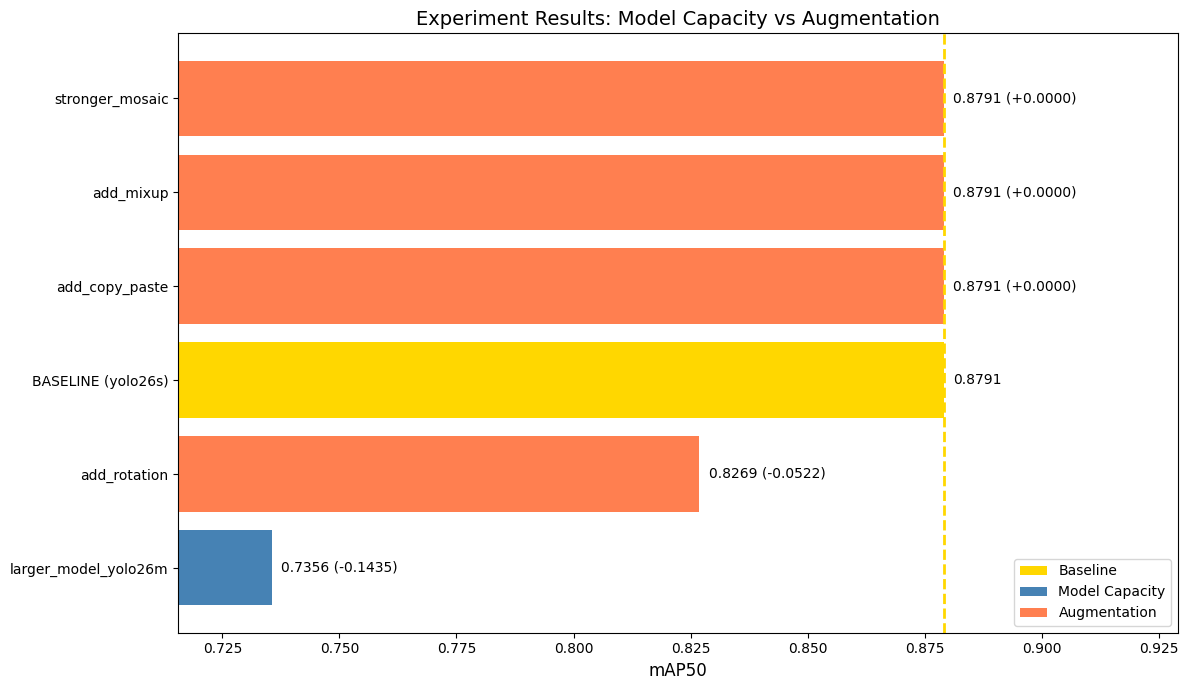

In [28]:
# Plot 1: All experiments compared to baseline
if sorted_results:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    names = [r['experiment'] for r in sorted_results]
    mAPs = [r['mAP50'] for r in sorted_results]
    
    # Color by hypothesis
    colors = []
    for r in sorted_results:
        if r['experiment'] == 'BASELINE (yolo26s)':
            colors.append('gold')
        elif r.get('hypothesis') == 'Model Capacity':
            colors.append('steelblue')
        elif r.get('hypothesis') == 'Overfitting':
            colors.append('coral')
        else:
            colors.append('gray')
    
    bars = ax.barh(range(len(names)), mAPs, color=colors)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_xlabel('mAP50', fontsize=12)
    ax.set_title('Experiment Results: Model Capacity vs Augmentation', fontsize=14)
    ax.invert_yaxis()
    
    # Baseline reference line
    ax.axvline(x=BASELINE_mAP50, color='gold', linestyle='--', linewidth=2,
               label=f'Baseline: {BASELINE_mAP50:.4f}')
    
    # Value labels
    for i, v in enumerate(mAPs):
        diff = v - BASELINE_mAP50
        label = f'{v:.4f} ({diff:+.4f})' if sorted_results[i]['experiment'] != 'BASELINE (yolo26s)' else f'{v:.4f}'
        ax.text(v + 0.002, i, label, va='center', fontsize=10)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='gold', label='Baseline'),
        Patch(facecolor='steelblue', label='Model Capacity'),
        Patch(facecolor='coral', label='Augmentation'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    # Set x-axis to show relevant range
    min_mAP = min(mAPs) - 0.02
    max_mAP = max(mAPs) + 0.05
    ax.set_xlim(min_mAP, max_mAP)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'hypothesis_comparison.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {output_dir / 'hypothesis_comparison.png'}")
    plt.show()

Saved: jupiter_inlet_model_vs_aug/augmentation_comparison.png


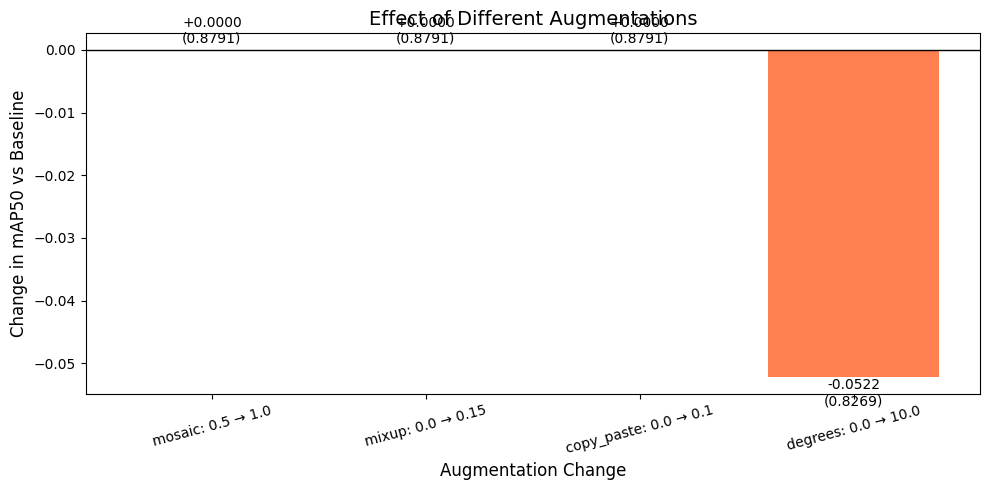

In [29]:
# Plot 2: Augmentation comparison only
aug_results = [r for r in successful if r.get('hypothesis') == 'Overfitting']

if aug_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Sort by mAP50
    aug_sorted = sorted(aug_results, key=lambda x: x['mAP50'], reverse=True)
    
    names = [r['change'] for r in aug_sorted]
    mAPs = [r['mAP50'] for r in aug_sorted]
    diffs = [r['mAP50'] - BASELINE_mAP50 for r in aug_sorted]
    
    colors = ['forestgreen' if d > 0 else 'coral' for d in diffs]
    
    bars = ax.bar(names, diffs, color=colors)
    ax.set_xlabel('Augmentation Change', fontsize=12)
    ax.set_ylabel('Change in mAP50 vs Baseline', fontsize=12)
    ax.set_title('Effect of Different Augmentations', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.tick_params(axis='x', rotation=15)
    
    # Value labels
    for i, (bar, diff, mAP) in enumerate(zip(bars, diffs, mAPs)):
        height = bar.get_height()
        ax.annotate(f'{diff:+.4f}\n({mAP:.4f})',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 5 if height >= 0 else -20),
                    textcoords="offset points",
                    ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'augmentation_comparison.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {output_dir / 'augmentation_comparison.png'}")
    plt.show()